In [78]:
# Checking spatial convergence and rayleigh damping for the gap flow.

In [79]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import argparse
import metpy
import metpy.calc as mpcalc
from metpy.units import units
import xarray as xr
import matplotlib.colors as colors
import matplotlib
import copy
import cmaps

In [80]:
savefig = True

rot = False

# Compare three files
if rot:
    nc_file1 = f'dcmip_lonlat_mountain_gap.nc'
    nc_file2 = f'dcmip_lonlat_mountain_gap_non_monotonic.nc'
else:
    nc_file1 = f'dcmip_lonlat_mountain_gap_no_rotation.nc'
    nc_file2 = f'dcmip_lonlat_mountain_gap_no_rotation_non_monotonic.nc'


In [81]:
run_path1 = '/glade/u/home/timand/LFRic_results/' + nc_file1
run_path2 = '/glade/u/home/timand/LFRic_results/' + nc_file2

nc1 = Dataset(run_path1)
nc2 = Dataset(run_path2)

In [82]:
lat = nc1['lat'][:] 
lon = nc1['lon'][:] 

print(np.size(lat), np.size(lon))

361 720


In [83]:
# Specify the size of the lon-lat crop, which
# will be centred around the equator for lat

lat_crop_up = 50.
lat_cent_down = -50.
lat_ticks = np.linspace(-40.,40.,5)

lon_crop_left = 140.
lon_crop_right = 280.
lon_ticks = np.linspace(140, 280, 8)

lon_inds = np.where((lon <= lon_crop_right) & (lon >= lon_crop_left))[0]
lat_inds = np.where((lat <= lat_crop_up) & (lat >= lat_cent_down))[0]

lat_crop = lat[lat_inds]
lon_crop = lon[lon_inds]

LON, LAT = np.meshgrid(lon_crop, lat_crop)

lon_lfric = lon_inds - 180

print(np.shape(lon_crop))

(280,)


In [84]:
# Time index to compare at
t_idx = 40

# z level to compare at, in m.
# For reference, the Gabersek, Durran paper
# plots at z = 300 m.
z_val = 300

title_size=16
label_size=14
small_size=12

In [85]:
# Interpolations of U and T

U_field_vals1 = np.transpose(nc1['u'][lon_lfric, lat_inds])
U_field_vals2 = np.transpose(nc2['u'][lon_lfric, lat_inds])

T_field_vals1 = np.transpose(nc1['T'][lon_lfric, lat_inds])
T_field_vals2 = np.transpose(nc2['T'][lon_lfric, lat_inds])

In [86]:
deg2rad = np.pi/180
T0 = 288
u0 = 10

# Normalised velocity perturbation:
U_field_vals1 = (U_field_vals1 - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))
U_field_vals2 = (U_field_vals2 - u0*np.cos(LAT*deg2rad))/(u0*np.cos(LAT*deg2rad))

# Temperature perturbation:
T_field_vals1 = T_field_vals1 - T0
T_field_vals2 = T_field_vals2 - T0

In [87]:
# What are the maximum values AWAY from the mountain??
lon_max_inds = np.where(np.logical_or((lon_crop <= 170),(lon_crop >= 190)))[0]

U_max_crop1 = U_field_vals1[:,lon_max_inds]
T_max_crop1 = T_field_vals1[:,lon_max_inds]

U_max_crop2 = U_field_vals2[:,lon_max_inds]
T_max_crop2 = T_field_vals2[:,lon_max_inds]


min value is -1.609607
max value is 3.233344


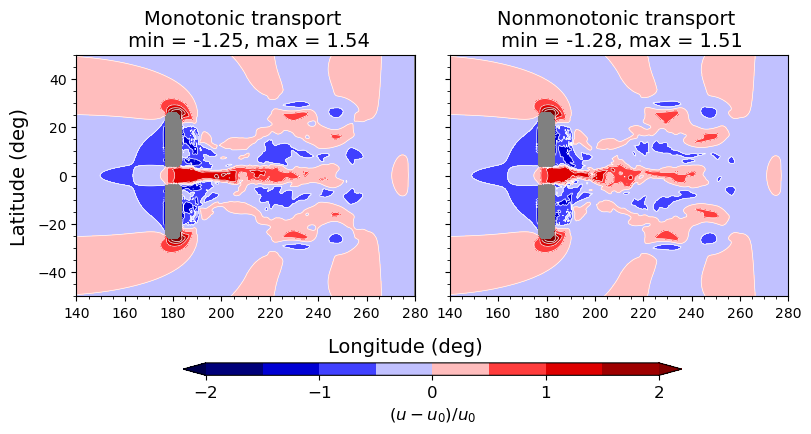

In [88]:
# Plot for U
U_cmap = matplotlib.cm.seismic
#U_cmap = matplotlib.cm.RdYlBu_r
#U_cmap.set_under('k')
#U_cmap.set_over('white')

#U_cmap = cmaps.ncl_default

U_max1 = np.nanmax(U_field_vals1)
U_max2 = np.nanmax(U_field_vals2)

U_min1 = np.nanmin(U_field_vals1)
U_min2 = np.nanmin(U_field_vals2)

U_maxmax = max(U_max1, U_max2)
U_minmin = min(U_min1, U_min2)

print('min value is', U_minmin)
print('max value is', U_maxmax)

if rot:
    fig, axes = plt.subplots(1,2, sharey=True, sharex=True, figsize = (8,5), layout="constrained")
else:
    fig, axes = plt.subplots(1,2, sharey=True, sharex=True, figsize = (8,6.5), layout="constrained")
    
(ax1, ax2) = axes

# Consistent scales between with/without rotation
U_conts = np.linspace(-2.0, 2.0, 9)
tick_range = np.linspace(-2.0, 2.0, 5)
norm = colors.TwoSlopeNorm(vmin=-2.0, vcenter=0, vmax=2.0)


plot1 = ax1.contourf(LON, LAT, U_field_vals1, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, U_field_vals2, levels = U_conts, cmap=U_cmap, norm=norm, extend = 'both')
#plot4 = ax4.contourf(LON, LAT, U_field_vals4)
U_title = 'Normalised velocity perturbation'

# If we want contours overlaid:
ax1.contour(LON, LAT, U_field_vals1, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
ax2.contour(LON, LAT, U_field_vals2, levels = U_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')

for ax in axes.flatten():
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))

    ax.set_aspect('equal')
    ax.set_facecolor("grey")

plt.xticks(lon_ticks)
plt.yticks(lat_ticks)

cb = plt.colorbar(plot2, ax=axes, ticks = tick_range, shrink=0.7, aspect=40, pad=0.1, location='bottom')
cb.set_label(label=r"$(u - u_0)/u_0$", size=small_size)
cb.ax.tick_params(labelsize=12)

# Overall extrema
#ax1.set_title(f'{dycore1} \n min = {np.round(U_min1,2)}, max = {np.round(U_max1,2)}', size=label_size)
#ax2.set_title(f'{dycore2} \n min = {np.round(U_min2,2)}, max = {np.round(U_max2,2)}', size=label_size)
#ax3.set_title(f'{dycore3} \n min = {np.round(U_min3,2)}, max = {np.round(U_max3,2)}', size=label_size)
#ax4.set_title(f'{dycore4} \n min = {np.round(U_min4,2)}, max = {np.round(U_max4,2)}', size=label_size)

# Extrema away from the mountain
ax1.set_title(f'Monotonic transport \n min = {np.min(U_max_crop1):.2f}, max = {np.max(U_max_crop1):.2f}', size=label_size)
ax2.set_title(f'Nonmonotonic transport \n min = {np.min(U_max_crop2):.2f}, max = {np.max(U_max_crop2):.2f}', size=label_size)

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size, x=0.5, y=0.14)

if savefig:
    if rot:
        plt.savefig('figures/gap_gungho_montonicity_with_rot_U.png')
    else:
        plt.savefig('figures/gap_gungho_montonicity_omega0_U.png')


min value is -5.65921
max value is 12.788025


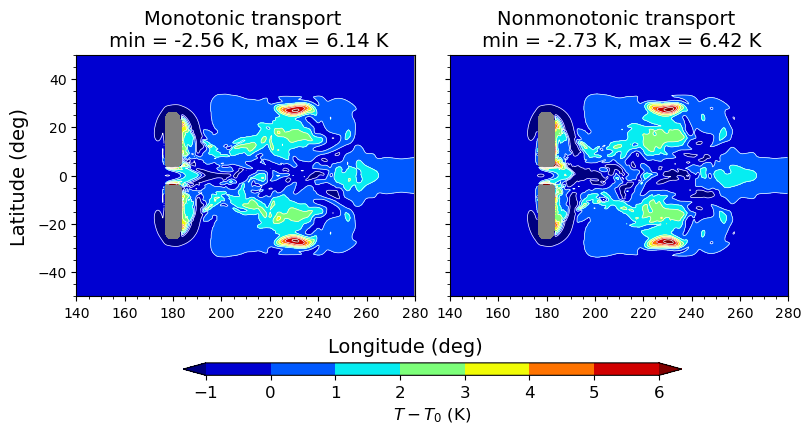

In [89]:
### T plot

T_cmap = copy.copy(matplotlib.cm.jet)
#T_cmap.set_under('k')
#T_cmap.set_over('deep red')

#T_cmap = cmaps.ncl_default

T_max1 = np.nanmax(T_field_vals1)
T_max2 = np.nanmax(T_field_vals2)

T_min1 = np.nanmin(T_field_vals1)
T_min2 = np.nanmin(T_field_vals2)

T_maxmax = max(T_max1, T_max2)
T_minmin = min(T_min1, T_min2)

print('min value is', T_minmin)
print('max value is', T_maxmax)

if rot:
    fig, axes = plt.subplots(1,2, sharey=True, sharex=True, figsize = (8,5), layout="constrained")
else:
    fig, axes = plt.subplots(1,2, sharey=True, sharex=True, figsize = (8,6.5), layout="constrained")

(ax1, ax2) = axes

T_conts = np.linspace(-1, 6, 8)
norm=None
tick_range = np.linspace(-1, 6, 8)
    
plot1 = ax1.contourf(LON, LAT, T_field_vals1, levels = T_conts, cmap=T_cmap, norm=norm, extend = 'both')
plot2 = ax2.contourf(LON, LAT, T_field_vals2, levels = T_conts, cmap=T_cmap, norm=norm, extend = 'both')

# If we want contours overlaid:
ax1.contour(LON, LAT, T_field_vals1, levels = T_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')
ax2.contour(LON, LAT, T_field_vals2, levels = T_conts, linestyles='solid', colors='white', linewidths=0.5, norm=norm, extend = 'both')

T_title = 'Temperature perturbation'
for ax in axes.flatten():
    ax.yaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(5))

    ax.set_aspect('equal')
    ax.set_facecolor("grey")

plt.xticks(lon_ticks)
plt.yticks(lat_ticks)

cb = plt.colorbar(plot2, ax=axes, ticks = tick_range, shrink=0.7, aspect=40, pad=0.1, location='bottom')
cb.set_label(label='$T - T_0$ (K)', size=small_size)
cb.ax.tick_params(labelsize=12)

# Extrema over the full domain
#ax1.set_title(f'{dycore1} \n min = {np.round(T_min1,2)} K, max = {np.round(T_max1,2)} K', size=label_size)
#ax2.set_title(f'{dycore2} \n min = {np.round(T_min2,2)} K, max = {np.round(T_max2,2)} K', size=label_size)
#ax3.set_title(f'{dycore3} \n min = {np.round(T_min3,2)} K, max = {np.round(T_max3,2)} K', size=label_size)
#ax4.set_title(f'{dycore4} \n min = {np.round(T_min4,2):.2f} K, max = {np.round(T_max4,2):.2f} K', size=label_size)

# Extrema away from the mountain
ax1.set_title(f'Monotonic transport \n min = {np.min(T_max_crop1):.2f} K, max = {np.max(T_max_crop1):.2f} K', size=label_size)
ax2.set_title(f'Nonmonotonic transport \n min = {np.min(T_max_crop2):.2f} K, max = {np.max(T_max_crop2):.2f} K', size=label_size)

fig.supylabel('Latitude (deg)', size=label_size)
fig.supxlabel('Longitude (deg)', size=label_size, x=0.5, y=0.14)

if savefig:
    if rot:
        plt.savefig('figures/gap_gungho_montonicity_with_rot_T.png')
    else:
        plt.savefig('figures/gap_gungho_montonicity_omega0_T.png')


In [90]:
# What about a vertical cross section?? Oh, I can't with the current data being only on one level.